<a href="https://colab.research.google.com/github/EsterNevess/residencia-ia/blob/main/Aula_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install langchain-core langchain-text-splitters sentence-transformers langchain-huggingface

In [3]:
from langchain_core.documents import Document
from langchain_huggingface import HuggingFaceEmbeddings

EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
embeddings = HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [4]:
documentos = [
    Document(
        page_content="Embeddings são representações vetoriais densas de texto.",
        metadata={"fonte": "arquivo_01.md", "pagina": 1, "tipo": "teoria", "tema": "embeddings"}
    ),

    Document(
        page_content="RAG combina recuperação de informação com geração de texto.",
        metadata={"tema": "RAG", "tags_lista": ["busca", "geração", "llm"]}
    ),

    Document(
        page_content="O LangChain padroniza a forma como os dados trafegam.",
        metadata={"tema": "LangChain", "detalhes_dicionario": {"versao": "core", "oficial": True}}
    ),

    Document(
        page_content="Tokenização é o processo de converter texto em números para a IA processar."
    ),

    Document(
        page_content="Chunking ajuda a não estourar o limite de contexto da API da OpenRouter.",
        metadata={"tema": "chunking", "importancia": "alta"}
    )
]

for i, doc in enumerate(documentos):
    print(f"--- Documento {i+1} ---")
    print(f"Conteúdo: {doc.page_content}")
    print(f"Metadados: {doc.metadata}\n")

print(f"Total de documentos criados: {len(documentos)}")

--- Documento 1 ---
Conteúdo: Embeddings são representações vetoriais densas de texto.
Metadados: {'fonte': 'arquivo_01.md', 'pagina': 1, 'tipo': 'teoria', 'tema': 'embeddings'}

--- Documento 2 ---
Conteúdo: RAG combina recuperação de informação com geração de texto.
Metadados: {'tema': 'RAG', 'tags_lista': ['busca', 'geração', 'llm']}

--- Documento 3 ---
Conteúdo: O LangChain padroniza a forma como os dados trafegam.
Metadados: {'tema': 'LangChain', 'detalhes_dicionario': {'versao': 'core', 'oficial': True}}

--- Documento 4 ---
Conteúdo: Tokenização é o processo de converter texto em números para a IA processar.
Metadados: {}

--- Documento 5 ---
Conteúdo: Chunking ajuda a não estourar o limite de contexto da API da OpenRouter.
Metadados: {'tema': 'chunking', 'importancia': 'alta'}

Total de documentos criados: 5


**Um print que exiba, para cada documento, o page content e o metadata segue abaixo!**

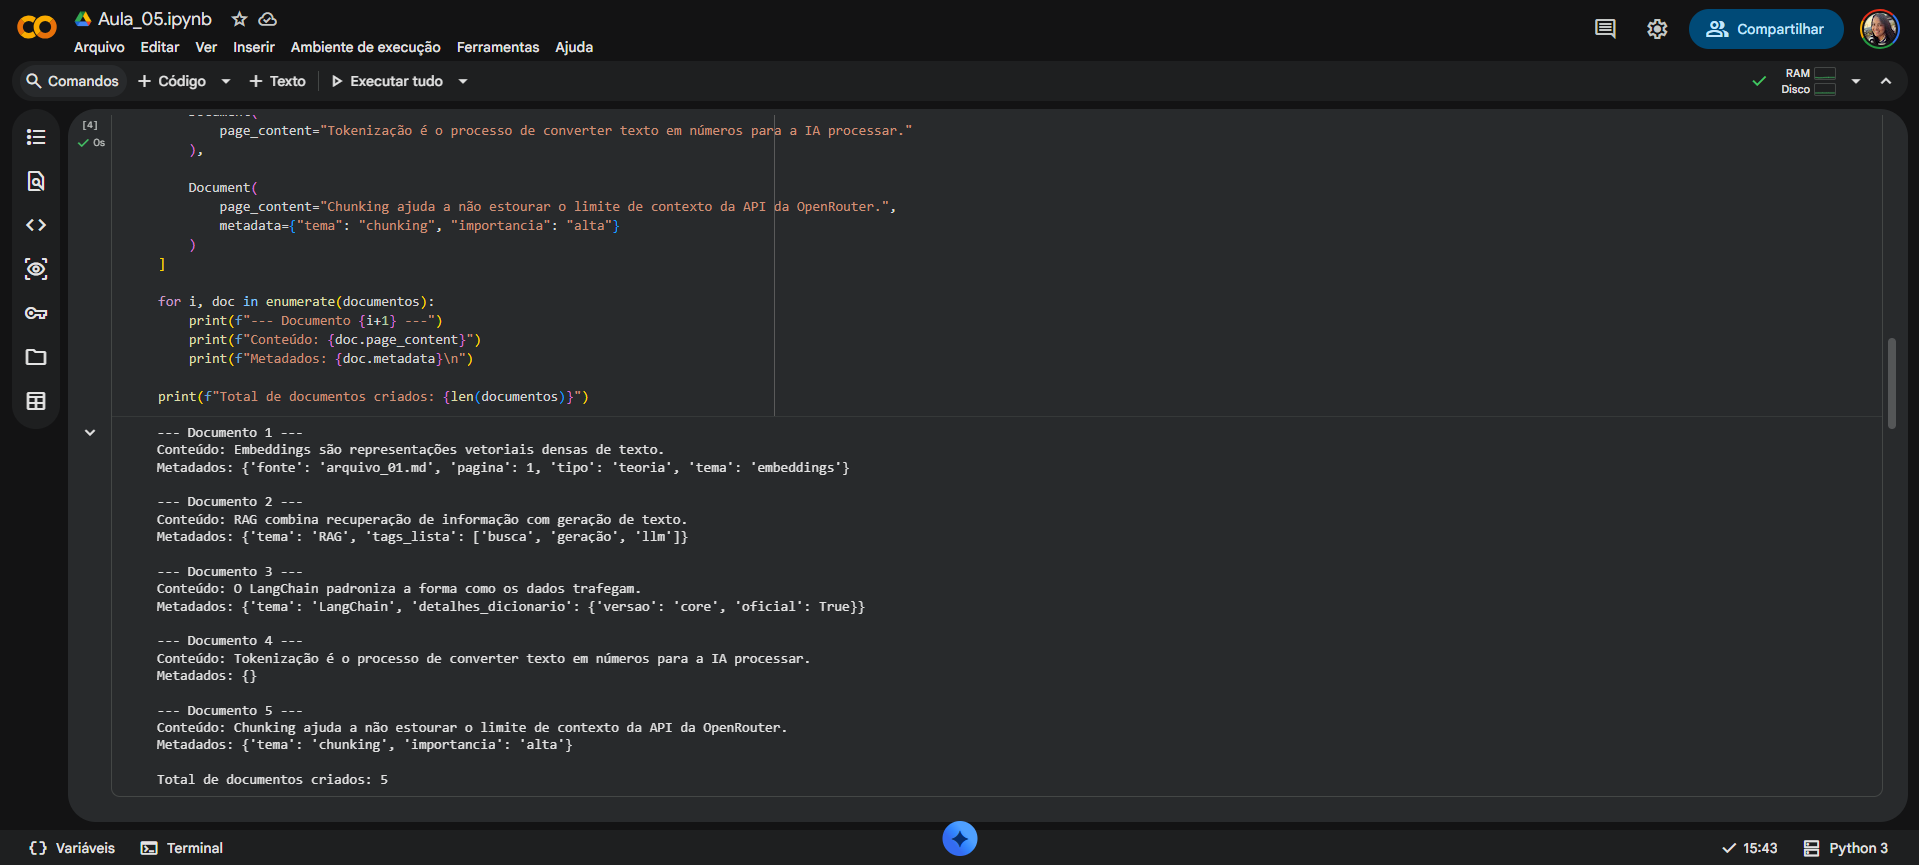

1. Que tipos de dados são aceitos dentro de metadata? O que acontece ao usar lista ou dicionário aninhado?

No objeto Document do LangChain, o metadata aceita qualquer tipo de dado válido em Python: textos, números, booleanos, listas e dicionários aninhados (como vimos no Documento 3 com 'detalhes_dicionario'). O LangChain não gera erro.

(Nota técnica para o futuro: Embora o objeto receba dicionários e listas sem problemas na memória, alguns Bancos Vetoriais — como o ChromaDB — exigem metadados simples de chave-valor e podem rejeitar dicionários aninhados na hora de criar o índice vetorial).


2. O que acontece se você criar um Document sem passar metadata?

Como demonstrado no Documento 4, se o parâmetro metadata for omitido, o LangChain assume por padrão um dicionário vazio ({}). O código não quebra e o objeto é criado normalmente.


In [1]:
!pip install chromadb langchain-chroma

In [7]:
import json
from langchain_chroma import Chroma

for doc in documentos:
    for chave, valor in doc.metadata.items():
        if isinstance(valor, dict):
            doc.metadata[chave] = json.dumps(valor)

vectorstore = Chroma.from_documents(
    documents=documentos,
    embedding=embeddings
)

print("Vector store criada com sucesso!")

Vector store criada com sucesso!


In [8]:
query = "O que é vetorização de texto?"
resultados = vectorstore.similarity_search(query, k=2)

print(f"--- Resultados para a busca: '{query}' ---")
for i, doc in enumerate(resultados):
    print(f"\nResultado {i+1}:")
    print(f"Conteúdo: {doc.page_content}")
    print(f"Metadados: {doc.metadata}")

--- Resultados para a busca: 'O que é vetorização de texto?' ---

Resultado 1:
Conteúdo: Embeddings são representações vetoriais densas de texto.
Metadados: {'fonte': 'arquivo_01.md', 'tema': 'embeddings', 'tipo': 'teoria', 'pagina': 1}

Resultado 2:
Conteúdo: O LangChain padroniza a forma como os dados trafegam.
Metadados: {'detalhes_dicionario': '{"versao": "core", "oficial": true}', 'tema': 'LangChain'}


In [9]:
query_filtrada = "como funciona a conversão"
resultados_filtrados = vectorstore.similarity_search(
    query_filtrada,
    k=2,
    filter={"tema": "embeddings"}
)

print(f"--- Resultados com filtro (tema = embeddings) ---")
for doc in resultados_filtrados:
    print(f"Conteúdo: {doc.page_content}")
    print(f"Metadados: {doc.metadata}")

--- Resultados com filtro (tema = embeddings) ---
Conteúdo: Embeddings são representações vetoriais densas de texto.
Metadados: {'fonte': 'arquivo_01.md', 'tipo': 'teoria', 'pagina': 1, 'tema': 'embeddings'}


## Exercício 2 - Schema de Metadados

### 1. Tabela com Schema Final

| Campo | Descrição |
| :--- | :--- |
| `fonte` | Nome do arquivo .md de origem |
| `documento_id` | Identificador único do documento |
| `chunk_index` | Posição do chunk dentro do documento |
| `estrategia` | Qual das 10 estratégias da Aula 04 gerou este chunk |
| `chunk_size` | Configuração usada (ex: 500) |
| `chunk_overlap` | Configuração usada (ex: 50) |
| `n_caracteres` | Tamanho real do chunk em caracteres |
| `pagina` *(Próprio 1)* | Número da página de onde o trecho foi extraído |
| `secao_titulo` *(Próprio 2)* | Título ou cabeçalho da seção/capítulo do texto |
| `data_processamento` *(Próprio 3)* | Data e hora em que o chunk foi gerado |

---

### 2. Justificativa dos Campos Próprios

1. **`pagina`**: Permite responder *"Em qual página exata do PDF original esta informação se encontra?"*, facilitando a verificação humana rápida.
2. **`secao_titulo`**: Permite responder *"Qual é o contexto hierárquico desse trecho no documento?"*, ajudando a filtrar buscas por capítulos específicos.
3. **`data_processamento`**: Permite responder *"Esta base vetorial está atualizada ou foi gerada por um script antigo?"*, garantindo governança do pipeline RAG.

---

### 3. Exemplo Preenchido em JSON (Chunk Real)

```json
{
  "page_content": "Os embeddings convertem palavras e frases em vetores numéricos de alta dimensão, permitindo a comparação semântica entre textos.",
  "metadata": {
    "fonte": "aula04_rag_introducao.md",
    "documento_id": "doc_001",
    "chunk_index": 3,
    "estrategia": "RecursiveCharacterTextSplitter",
    "chunk_size": 500,
    "chunk_overlap": 50,
    "n_caracteres": 138,
    "pagina": 4,
    "secao_titulo": "Introdução aos Vetores",
    "data_processamento": "2026-08-12 15:30:00"
  }
}


1. Qual campo incluir para citar a fonte na resposta final do RAG?

Os campos essenciais seriam fonte combinado com pagina (ou secao_titulo). Com eles, o sistema pode responder informando exatamente: "Fonte: apostila.pdf, Página 4".

2. Por que chunk_index é útil caso o trecho esteja cortado?

O chunk_index permite implementar o encadeamento de contexto (Neighbor Chunk Retrieval). Se uma busca retornar o chunk_index: 3 cortado ao meio, o sistema pode buscar na Vector Store os chunks vizinhos (chunk_index: 2 e chunk_index: 4) para reconstruir o raciocínio completo antes de enviar para a LLM.
